In [1]:
import sys
import os
current_dir = os.path.abspath('')
os.chdir(current_dir)
sys.path.append(os.path.join(current_dir,'..','code','BalancingControl'))

import two_stage_utils as tu
import inference_utils as iu
import inference as inf

torch threads 1


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running on device cpu
torch threads 1


In [2]:
import torch
import pyro

import os
from scipy.io import loadmat
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import glob
import pickle
import json
import gc

from scipy.stats import ttest_1samp
from scipy.stats import pearsonr

In [3]:
results_folder = "results"
inference_folder = os.path.join(results_folder, "inference")
model_comp_folder = os.path.join(results_folder, "model_comparison")

mask_file_name = "mask.txt"
processed_data_folder = os.path.join("processed_data")
mask_file = os.path.join(processed_data_folder, mask_file_name)

non_fit_fname = "non_fit_file.txt"
non_fit_file = os.path.join(model_comp_folder, non_fit_fname)

full_data_fname = "full_data.csv"
full_data_file = os.path.join(processed_data_folder, full_data_fname)

full_data_df = pd.read_csv(full_data_file)

n_agents = 188

num_steps = 600

In [4]:
trials =  201#number of trials
T = 3 #number of time steps in each trial
nb = 4 # number of bandits, ie second level rewards
ns = 3+nb #number of states
no = ns #number of observations
na = 2 #number of actions
npi = na**(T-1) #number of policies
nr = 2 #number of rewards
never_reward = ns-nb # states that dont generate rewards

# prob for invalid answer (e.g. no reply). Same frequency as in the real data
# prob for invalid answer (e.g. no reply). Same frequency as in the real data
with open(mask_file, "rb") as f:
    all_mask = pickle.load(f)
# simulations will be done with the same missing actions as in the data.
exp_mask = torch.tensor(all_mask).permute((1,0))
p_valid = exp_mask.sum()/(exp_mask.shape[0]*exp_mask.shape[1])
print(p_valid)

# make global parameter dict:
global_experiment_parameters = {"trials": trials, "T": T, "nb": nb, "ns": ns, "no": no, "na": na, "npi": npi, "nr": nr, "never_reward": never_reward, "p_invalid": p_valid, "mask": exp_mask}

tensor(0.9766)


/tmp/ipykernel_667910/1548601007.py:16: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  exp_mask = torch.tensor(all_mask).permute((1,0))


In [5]:
#generating probability of observations in each state / unity matrix
A = torch.eye(no)


#state transition generative probability (matrix)
B = torch.zeros((ns, ns, na))
b1 = 0.7
nb1 = 1.-b1
b2 = 0.7
nb2 = 1.-b2

B[:,:,0] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [ b1,  0,  0,  0,  0,  0,  0,],
                         [nb1,  0,  0,  0,  0,  0,  0,],
                         [  0,  1,  0,  1,  0,  0,  0,],
                         [  0,  0,  1,  0,  1,  0,  0,],
                         [  0,  0,  0,  0,  0,  1,  0,],
                         [  0,  0,  0,  0,  0,  0,  1,],])

B[:,:,1] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [nb2,  0,  0,  0,  0,  0,  0,],
                         [ b2,  0,  0,  0,  0,  0,  0,],
                         [  0,  0,  0,  1,  0,  0,  0,],
                         [  0,  0,  0,  0,  1,  0,  0,],
                         [  0,  1,  0,  0,  0,  1,  0,],
                         [  0,  0,  1,  0,  0,  0,  1,],])

# add to parameter dict
global_experiment_parameters["A"] = A
global_experiment_parameters["B"] = B

In [6]:
def convert_data_for_agent(full_data_df):

    mask = full_data_df.loc[(full_data_df["step_index"]==1)]
    mask_formatted = torch.stack([torch.from_numpy(mask.loc[mask["subject"]==i]["mask"].to_numpy()) for i in range(n_agents)])

    actions1 = full_data_df.loc[(full_data_df["step_index"]==1)]
    actions1_formatted = torch.stack([torch.from_numpy(actions1.loc[actions1["subject"]==i]["first_stage_actions"].to_numpy()) for i in range(n_agents)])

    actions2 = full_data_df.loc[(full_data_df["step_index"]==2)]
    actions2_formatted = torch.stack([torch.from_numpy(actions2.loc[actions2["subject"]==i]["second_stage_actions"].to_numpy()) for i in range(n_agents)])

    print("possible actions1", torch.unique(actions1_formatted[mask_formatted]))
    print("possible actions2", torch.unique(actions2_formatted[mask_formatted]))

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    actions1_formatted = torch.where(mask_formatted, actions1_formatted, -1)
    actions2_formatted = torch.where(mask_formatted, actions2_formatted, -1)

    actions = torch.stack([actions1_formatted, actions2_formatted], dim=-1).permute((1,2,0))
    #print(actions.permute((0,2,1))[mask_formatted])
    # agent counts from zero:
    actions = actions-1.

    states1 = full_data_df.loc[(full_data_df["step_index"]==1)]
    # agent counts from zero, hence -1 at the end:
    states1_formatted = torch.stack([torch.from_numpy(states1.loc[states1["subject"]==i]["first_stage_states"].to_numpy()) for i in range(n_agents)]) - 1
     
    states2 = full_data_df.loc[(full_data_df["step_index"]==2)]
    # agent counts from zero, hence -1 at the end:
    states2_formatted = torch.stack([torch.from_numpy(states2.loc[states2["subject"]==i]["second_stage_states"].to_numpy()) for i in range(n_agents)]) - 1

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    states1_formatted = torch.where(mask_formatted, states1_formatted, -1)
    states2_formatted = torch.where(mask_formatted, states2_formatted, -1)
    # create third time step states:
    states3_formatted = states2_formatted+2 + (actions2_formatted-1)*2
    states3_formatted = torch.where(mask_formatted, states3_formatted, -1)


    print("possible states1", torch.unique(states1_formatted[mask_formatted]))
    print("possible states2", torch.unique(states2_formatted[mask_formatted]))
    print("possible states3", torch.unique(states3_formatted[mask_formatted]))

    states = torch.stack([states1_formatted, states2_formatted, states3_formatted], dim=-1).permute((1,2,0))

    # agent views r=2 as "no reward", may instead give negative reward as in Otto et al:
    rewards1_formatted = torch.zeros_like(states1_formatted) #+ 2

    rewards2_formatted = rewards1_formatted

    # create third time step rewards = second stage rewards:
    rewards3 = full_data_df.loc[(full_data_df["step_index"]==2)]
    rewards3_formatted = torch.stack([torch.from_numpy(rewards3.loc[rewards3["subject"]==i]["second_stage_rewards"].to_numpy()) for i in range(n_agents)])

    print("possible rewards1", torch.unique(rewards1_formatted[mask_formatted]))
    print("possible rewards2", torch.unique(rewards2_formatted[mask_formatted]))
    print("possible rewards3", torch.unique(rewards3_formatted[mask_formatted]))

    # write minus one into invalid regions (currently returns integer overflow below when converted to int)
    rewards1_formatted = torch.where(mask_formatted, rewards1_formatted, 0)
    rewards2_formatted = torch.where(mask_formatted, rewards2_formatted, 0)
    rewards3_formatted = torch.where(mask_formatted, rewards3_formatted, 0)

    rewards = torch.stack([rewards1_formatted, rewards2_formatted, rewards3_formatted], dim=-1).permute((1,2,0))


    data_dict = {"observations": states.long(), "rewards": rewards.long(), "actions": actions.long(), "valid": mask_formatted.permute((1,0))}

    return data_dict

data = convert_data_for_agent(full_data_df)

print(data)

possible actions1 tensor([1., 2.], dtype=torch.float64)
possible actions2 tensor([1., 2.], dtype=torch.float64)
possible states1 tensor([0.], dtype=torch.float64)
possible states2 tensor([1., 2.], dtype=torch.float64)
possible states3 tensor([3., 4., 5., 6.], dtype=torch.float64)
possible rewards1 tensor([0.], dtype=torch.float64)
possible rewards2 tensor([0.], dtype=torch.float64)
possible rewards3 tensor([0., 1.], dtype=torch.float64)
{'observations': tensor([[[ 0,  0,  0,  ..., -1,  0, -1],
         [ 1,  1,  2,  ..., -1,  1, -1],
         [ 3,  3,  4,  ..., -1,  5, -1]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  1,  1,  2],
         [ 5,  3,  6,  ...,  3,  3,  4]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  2,  2,  1],
         [ 5,  3,  6,  ...,  6,  6,  3]],

        ...,

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  1,  2,  ...,  1,  2,  1],
         [ 3,  5,  4,  ...,  3,  6,  3]],

        [[ 0,  0, -1,  ..., 

In [7]:
def load_BCC_results(learn_rewards, learn_habit, learn_cached, use_h, base_dir, global_experiment_parameters, valid, fname_base, num_steps, data, param_names):    

    # set up agent
    bayes_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, 
                                                    global_experiment_parameters, data["valid"], remove_old=False, 
                                                    use_h=use_h)

    print('analyzing '+str(n_agents)+' data sets')

    resample = False

    # set up inference
    inferrer = inf.GeneralGroupInference(bayes_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    if resample:
        mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
    else:
        mean_df, sample_df, locs_df = iu.load_samples(base_dir, fname_str) 

    return mean_df, sample_df, locs_df

In [8]:
def load_MFMB_results(learn_prior, use_orig, use_p, restrict_alpha, min_alpha, max_dt, base_dir, global_experiment_parameters, valid, fname_base, num_steps, data, param_names):    

    # set up agent
    mfmb_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, min_alpha, base_dir, global_experiment_parameters, valid, remove_old=False)

    print('analyzing '+str(n_agents)+' data sets')

    resample = False

    # set up inference
    inferrer = inf.GeneralGroupInference(mfmb_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    if resample:
        mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
    else:
        mean_df, sample_df, locs_df = iu.load_samples(base_dir, fname_str) 

    return mean_df, sample_df, locs_df

In [9]:
def calculate_log_likelihood_mean_param(data, agent, locs_df, npars, trials, T):

    # question: what do with nan trials? If I ignore them, they will decrease the likelihood and make subject seem to fit better. If I make them uniform, itll decrease by a lot?
    # this is the likelihood of the average parameter
    # answer: multiply the log by 0

    n_agents = data["actions"].shape[-1]

    log_like = []
    
    # print("locs df 0", locs_df["locs"+str(0)].shape)
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(locs_df[locs_df["subject"]==i]["locs"+str(k)].mean())
        locs_list.append(torch.tensor(locs_subs).float())

    locs = torch.stack(locs_list, dim=-1)
    # print("resulting locs", locs.shape)
    assert(locs.shape[0]==n_agents)

    agent.reset(locs)

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                test = probs > 1
                if test.sum()>0:
                    print(probs)
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)[0]
                test = likes > 1
                if test.sum()>0:
                    print(likes)

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.5]))

                test = masked_probs > 1
                if test.sum()>0:
                    print("masked", masked_probs)

                log_like.append(torch.log(masked_probs))#*data["valid"][tau].long())

                test = torch.exp(log_like[-1]) > 1
                if test.sum()>0:
                    print("log like", torch.exp(log_like[-1]))


    log_like = torch.stack(log_like, dim=0)

    test = torch.exp(log_like) > 1
    if test.sum()>0:
        print("total")

    return log_like
    

# Define agents and load results

## BCC2 planning agent

In [10]:
# load BCC2 data

# set parameters and their names

learn_rewards = True
learn_habit = False
use_h = False
learn_cached = False

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_planning"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_repetition"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# prepare for saving results
# make base filename and folder string
BCC2_p_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(BCC2_p_agent_type)

BCC2_p_agent_params = {"learn_rewards": learn_rewards, "learn_habit": learn_habit, 
                       "learn_cached": learn_cached, "use_h": use_h,
                       "param_names": param_names, "param_ranges": param_ranges}

BCC_2pars_planning


In [11]:
BCC2_p_fname_base = BCC2_p_agent_type+"_inference_"
print(BCC2_p_fname_base)
# define folder where we want to save data
BCC2_p_base_dir = os.path.join(inference_folder,BCC2_p_fname_base[:-1])

BCC2_p_mean_df, BCC2_p_sample_df, BCC2_p_locs_df = \
    load_BCC_results(BCC2_p_agent_params["learn_rewards"], BCC2_p_agent_params["learn_habit"], 
                     BCC2_p_agent_params["learn_cached"], BCC2_p_agent_params["use_h"],
                     BCC2_p_base_dir, global_experiment_parameters, exp_mask, BCC2_p_fname_base, 
                     num_steps, data, BCC2_p_agent_params["param_names"])

BCC2_p_agent = tu.set_up_Bayesian_inference_agent(n_agents, BCC2_p_agent_params["learn_rewards"], BCC2_p_agent_params["learn_habit"], 
                                                    BCC2_p_agent_params["learn_cached"], BCC2_p_base_dir, global_experiment_parameters, 
                                                    data["valid"], remove_old=False, use_h=BCC2_p_agent_params["use_h"])

BCC2_p_log_like = iu.calculate_log_likelihood(data, BCC2_p_agent, BCC2_p_locs_df, len(BCC2_p_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC2_p_choice_log_like = -calculate_log_likelihood_mean_param(data, BCC2_p_agent, BCC2_p_locs_df, len(BCC2_p_agent_params["param_names"]), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC_2pars_planning_inference_
2
analyzing 188 data sets
2


/home/sarah/src/TwoStageStrategies/Chen_et_al_data/../code/BalancingControl/perception.py:142: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  self.big_trans_matrix = ar.stack([ar.stack([generative_model_states[:,:,policies[pi,t]] for pi in range(self.npi)]) for t in range(self.T-1)]).T.to(device)
/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/

37 participants have random behavior under the model (p>0.01)


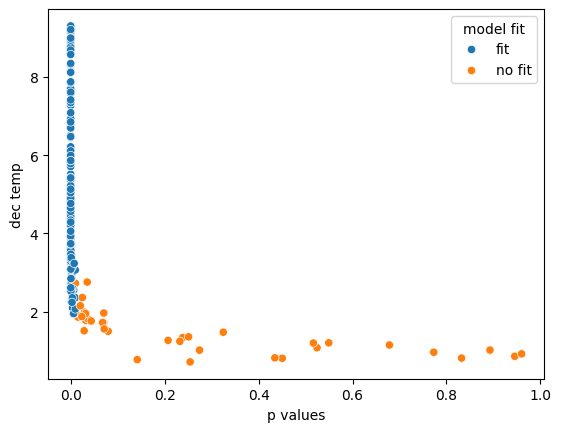

[7, 26, 28, 32, 34, 36, 40, 51, 63, 69, 82, 84, 89, 92, 100, 106, 108, 119, 120, 123, 128, 129, 140, 143, 144, 145, 152, 155, 157, 166, 167, 170, 174, 175, 176, 181, 183]


In [12]:
ttest_results = []
BCC2_p_didnt_fit_choice = []
p_values = []
didnt_fit_str = []

null_hypothesis = -torch.log(torch.tensor(0.5))
significance_level = 0.01

random_choice_log_like = -torch.log(torch.tensor(1./na))*trials*(T-1)

for n in range(n_agents):
    ttest_results.append(ttest_1samp(BCC2_p_choice_log_like[:,n], null_hypothesis))
    p_values.append(ttest_results[-1].pvalue)
    #print(ttest_results[-1])
    if ttest_results[-1].pvalue > significance_level:
        #print(n)
        #print(ttest_results[-1])
        BCC2_p_didnt_fit_choice.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")

    # if BCC2_p_log_like[n] >= random_choice_log_like and BCC2_p_didnt_fit_choice[-1] != n:
    #     print("ttest and log like not in agreement", n)

    # if BCC2_p_log_like[n] < random_choice_log_like and n in BCC2_p_didnt_fit_choice:
    #     print("ttest and log like not in agreement", n)

p_values = torch.tensor(p_values)

print(len(BCC2_p_didnt_fit_choice), "participants have random behavior under the model (p>"+str(significance_level)+")")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"p values": p_values, "model fit": didnt_fit_str,
                                            "dec temp": BCC2_p_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="p values", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC2_p_1_mean_df["inferred dec temp"])

print(BCC2_p_didnt_fit_choice)


6 participants have random behavior compared to L0


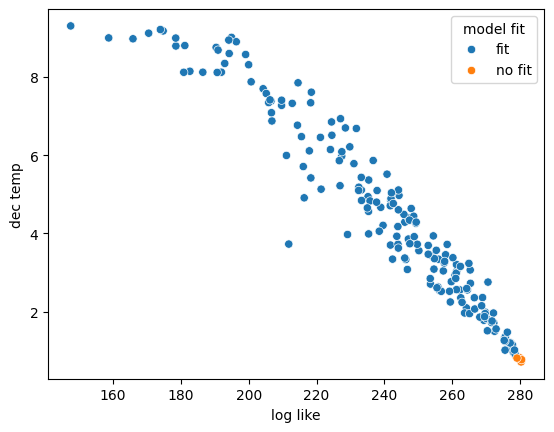

[82, 89, 100, 129, 143, 181]


In [13]:
ttest_results = []
BCC2_p_didnt_fit_L0 = []
p_values = []
didnt_fit_str = []

random_choice_log_like = -torch.log(torch.tensor(1./na))*trials*(T-1)

for n in range(n_agents):

    if BCC2_p_log_like[n] >= random_choice_log_like:
        #print(n)
        #print(ttest_results[-1])
        BCC2_p_didnt_fit_L0.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")


p_values = torch.tensor(p_values)

print(len(BCC2_p_didnt_fit_L0), "participants have random behavior compared to L0")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"log like": BCC2_p_log_like, "model fit": didnt_fit_str,
                                            "dec temp": BCC2_p_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="log like", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC2_p_1_mean_df["inferred dec temp"])

print(BCC2_p_didnt_fit_L0)


## BCC4 planning repetition agent

In [14]:
# BCC4_planning_repetition agent

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = False

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_planning"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_repetition"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# prepare for saving results
# make base filename and folder string
BCC4_p_r_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(BCC4_p_r_agent_type)

BCC4_p_r_agent_params = {"learn_rewards": learn_rewards, "learn_habit": learn_habit, 
                       "learn_cached": learn_cached, "use_h": use_h,
                       "param_names": param_names, "param_ranges": param_ranges}

BCC_4pars_planning_repetition_weight


In [15]:
BCC4_p_r_fname_base = BCC4_p_r_agent_type+"_inference_"
print(BCC4_p_r_fname_base)
# define folder where we want to save data
BCC4_p_r_base_dir = os.path.join(inference_folder,BCC4_p_r_fname_base[:-1])

BCC4_p_r_mean_df, BCC4_p_r_sample_df, BCC4_p_r_locs_df = \
    load_BCC_results(BCC4_p_r_agent_params["learn_rewards"], BCC4_p_r_agent_params["learn_habit"], 
                     BCC4_p_r_agent_params["learn_cached"], BCC4_p_r_agent_params["use_h"],
                     BCC4_p_r_base_dir, global_experiment_parameters, exp_mask, BCC4_p_r_fname_base, 
                     num_steps, data, BCC4_p_r_agent_params["param_names"])

BCC4_p_r_agent = tu.set_up_Bayesian_inference_agent(n_agents, BCC4_p_r_agent_params["learn_rewards"], BCC4_p_r_agent_params["learn_habit"], 
                                                    BCC4_p_r_agent_params["learn_cached"], BCC4_p_r_base_dir, global_experiment_parameters, 
                                                    data["valid"], remove_old=False, use_h=BCC4_p_r_agent_params["use_h"])

BCC4_p_r_log_like = iu.calculate_log_likelihood(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_r_choice_log_like = -calculate_log_likelihood_mean_param(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_agent_params["param_names"]), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC_4pars_planning_repetition_weight_inference_
4
analyzing 188 data sets


4


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

32 participants have random behavior under the model (p>0.01)


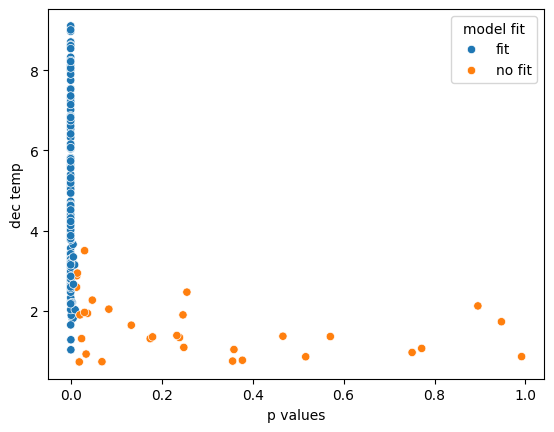

[7, 26, 34, 51, 82, 84, 89, 92, 100, 106, 108, 114, 115, 119, 120, 123, 129, 135, 143, 144, 145, 152, 155, 157, 164, 167, 170, 174, 175, 176, 181, 183]


In [16]:
ttest_results = []
BCC4_p_r_didnt_fit_choice = []
p_values = []
didnt_fit_str = []

null_hypothesis = -torch.log(torch.tensor(0.5))
significance_level = 0.01

random_choice_log_like = -torch.log(torch.tensor(1./na))*trials*(T-1)

for n in range(n_agents):
    ttest_results.append(ttest_1samp(BCC4_p_r_choice_log_like[:,n], null_hypothesis))
    p_values.append(ttest_results[-1].pvalue)
    #print(ttest_results[-1])
    if ttest_results[-1].pvalue > significance_level:
        #print(n)
        #print(ttest_results[-1])
        BCC4_p_r_didnt_fit_choice.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")

    # if BCC4_p_r_log_like[n] >= random_choice_log_like and BCC4_p_r_didnt_fit_choice[-1] != n:
    #     print("ttest and log like not in agreement", n)

    # if BCC4_p_r_log_like[n] < random_choice_log_like and n in BCC4_p_r_didnt_fit_choice:
    #     print("ttest and log like not in agreement", n)

p_values = torch.tensor(p_values)

print(len(BCC4_p_r_didnt_fit_choice), "participants have random behavior under the model (p>"+str(significance_level)+")")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"p values": p_values, "model fit": didnt_fit_str,
                                            "dec temp": BCC4_p_r_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="p values", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC4_p_r_1_mean_df["inferred dec temp"])

print(BCC4_p_r_didnt_fit_choice)


15 participants have random behavior compared to L0


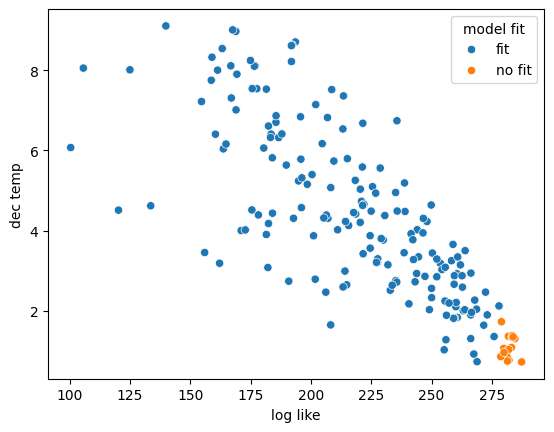

[82, 84, 89, 92, 106, 108, 119, 123, 129, 143, 152, 155, 157, 170, 183]


In [17]:
ttest_results = []
BCC4_p_r_didnt_fit_L0 = []
p_values = []
didnt_fit_str = []

random_choice_log_like = -torch.log(torch.tensor(1./na))*trials*(T-1)

for n in range(n_agents):

    if BCC4_p_r_log_like[n] >= random_choice_log_like:
        #print(n)
        #print(ttest_results[-1])
        BCC4_p_r_didnt_fit_L0.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")


p_values = torch.tensor(p_values)

print(len(BCC4_p_r_didnt_fit_L0), "participants have random behavior compared to L0")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"log like": BCC4_p_r_log_like, "model fit": didnt_fit_str,
                                            "dec temp": BCC4_p_r_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="log like", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC4_p_r_1_mean_df["inferred dec temp"])

print(BCC4_p_r_didnt_fit_L0)


## BCC4 planning cached agent

In [18]:
# BCC4_planning_cached agent

learn_rewards = True
learn_habit = False
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_planning"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_repetition"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# prepare for saving results
# make base filename and folder string
BCC4_p_c_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(BCC4_p_c_agent_type)

BCC4_p_c_agent_params = {"learn_rewards": learn_rewards, "learn_habit": learn_habit, 
                       "learn_cached": learn_cached, "use_h": use_h,
                       "param_names": param_names, "param_ranges": param_ranges}

BCC_4pars_planning_cached


In [19]:
BCC4_p_c_fname_base = BCC4_p_c_agent_type+"_inference_"
print(BCC4_p_c_fname_base)
# define folder where we want to save data
BCC4_p_c_base_dir = os.path.join(inference_folder,BCC4_p_c_fname_base[:-1])

BCC4_p_c_mean_df, BCC4_p_c_sample_df, BCC4_p_c_locs_df = \
    load_BCC_results(BCC4_p_c_agent_params["learn_rewards"], BCC4_p_c_agent_params["learn_habit"], 
                     BCC4_p_c_agent_params["learn_cached"], BCC4_p_c_agent_params["use_h"],
                     BCC4_p_c_base_dir, global_experiment_parameters, exp_mask, BCC4_p_c_fname_base, 
                     num_steps, data, BCC4_p_c_agent_params["param_names"])

BCC4_p_c_agent = tu.set_up_Bayesian_inference_agent(n_agents, BCC4_p_c_agent_params["learn_rewards"], BCC4_p_c_agent_params["learn_habit"], 
                                                    BCC4_p_c_agent_params["learn_cached"], BCC4_p_c_base_dir, global_experiment_parameters, 
                                                    data["valid"], remove_old=False, use_h=BCC4_p_c_agent_params["use_h"])

BCC4_p_c_log_like = iu.calculate_log_likelihood(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_c_choice_log_like = -calculate_log_likelihood_mean_param(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_agent_params["param_names"]), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC_4pars_planning_cached_inference_
4
analyzing 188 data sets
4


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

41 participants have random behavior under the model (p>0.01)


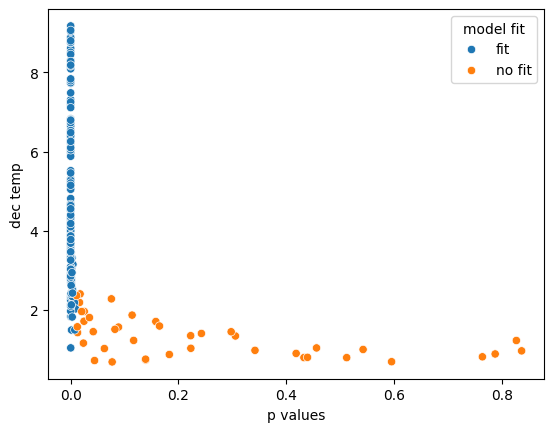

[7, 26, 28, 32, 34, 36, 41, 51, 57, 63, 69, 82, 84, 88, 89, 92, 100, 106, 108, 114, 117, 119, 123, 128, 129, 140, 143, 144, 145, 152, 155, 157, 163, 166, 167, 170, 174, 175, 176, 181, 183]


In [20]:
ttest_results = []
BCC4_p_c_didnt_fit_choice = []
p_values = []
didnt_fit_str = []

null_hypothesis = -torch.log(torch.tensor(0.5))
significance_level = 0.01

random_choice_log_like = -torch.log(torch.tensor(1./na))*trials*(T-1)

for n in range(n_agents):
    ttest_results.append(ttest_1samp(BCC4_p_c_choice_log_like[:,n], null_hypothesis))
    p_values.append(ttest_results[-1].pvalue)
    #print(ttest_results[-1])
    if ttest_results[-1].pvalue > significance_level:
        #print(n)
        #print(ttest_results[-1])
        BCC4_p_c_didnt_fit_choice.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")

    # if BCC4_p_c_log_like[n] >= random_choice_log_like and BCC4_p_c_didnt_fit_choice[-1] != n:
    #     print("ttest and log like not in agreement", n)

    # if BCC4_p_c_log_like[n] < random_choice_log_like and n in BCC4_p_c_didnt_fit_choice:
    #     print("ttest and log like not in agreement", n)

p_values = torch.tensor(p_values)

print(len(BCC4_p_c_didnt_fit_choice), "participants have random behavior under the model (p>"+str(significance_level)+")")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"p values": p_values, "model fit": didnt_fit_str,
                                            "dec temp": BCC4_p_c_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="p values", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC4_p_c_1_mean_df["inferred dec temp"])

print(BCC4_p_c_didnt_fit_choice)


7 participants have random behavior compared to L0


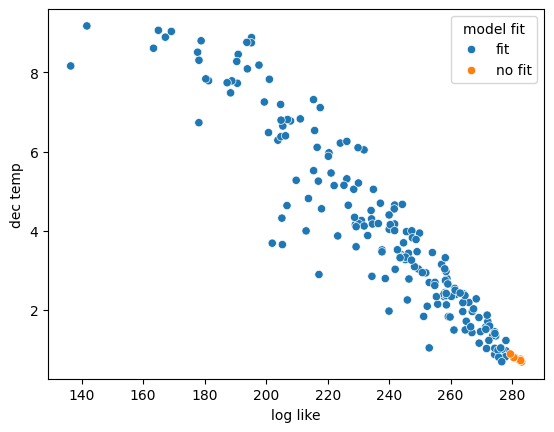

[82, 89, 100, 129, 143, 155, 170]


In [21]:
ttest_results = []
BCC4_p_c_didnt_fit_L0 = []
p_values = []
didnt_fit_str = []

random_choice_log_like = -torch.log(torch.tensor(1./na))*trials*(T-1)

for n in range(n_agents):

    if BCC4_p_c_log_like[n] >= random_choice_log_like:
        #print(n)
        #print(ttest_results[-1])
        BCC4_p_c_didnt_fit_L0.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")


p_values = torch.tensor(p_values)

print(len(BCC4_p_c_didnt_fit_L0), "participants have random behavior compared to L0")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"log like": BCC4_p_c_log_like, "model fit": didnt_fit_str,
                                            "dec temp": BCC4_p_c_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="log like", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC4_p_c_1_mean_df["inferred dec temp"])

print(BCC4_p_c_didnt_fit_L0)


## BCC6 planning repetition cached agent

In [22]:
# BCC4_planning_cached agent

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_planning"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_repetition"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# prepare for saving results
# make base filename and folder string
BCC6_p_r_c_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(BCC6_p_r_c_agent_type)

BCC6_p_r_c_agent_params = {"learn_rewards": learn_rewards, "learn_habit": learn_habit, 
                       "learn_cached": learn_cached, "use_h": use_h,
                       "param_names": param_names, "param_ranges": param_ranges}

BCC_6pars_planning_repetition_weight_cached


In [23]:
BCC6_p_r_c_fname_base = BCC6_p_r_c_agent_type+"_inference_"
print(BCC6_p_r_c_fname_base)
# define folder where we want to save data
BCC6_p_r_c_base_dir = os.path.join(inference_folder,BCC6_p_r_c_fname_base[:-1])

BCC6_p_r_c_mean_df, BCC6_p_r_c_sample_df, BCC6_p_r_c_locs_df = \
    load_BCC_results(BCC6_p_r_c_agent_params["learn_rewards"], BCC6_p_r_c_agent_params["learn_habit"], 
                     BCC6_p_r_c_agent_params["learn_cached"], BCC6_p_r_c_agent_params["use_h"],
                     BCC6_p_r_c_base_dir, global_experiment_parameters, exp_mask, BCC6_p_r_c_fname_base, 
                     num_steps, data, BCC6_p_r_c_agent_params["param_names"])

BCC6_p_r_c_agent = tu.set_up_Bayesian_inference_agent(n_agents, BCC6_p_r_c_agent_params["learn_rewards"], BCC6_p_r_c_agent_params["learn_habit"], 
                                                    BCC6_p_r_c_agent_params["learn_cached"], BCC6_p_r_c_base_dir, global_experiment_parameters, 
                                                    data["valid"], remove_old=False, use_h=BCC6_p_r_c_agent_params["use_h"])

BCC6_p_r_c_log_like = iu.calculate_log_likelihood(data, BCC6_p_r_c_agent, BCC6_p_r_c_locs_df, len(BCC6_p_r_c_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC6_p_r_c_choice_log_like = -calculate_log_likelihood_mean_param(data, BCC6_p_r_c_agent, BCC6_p_r_c_locs_df, len(BCC6_p_r_c_agent_params["param_names"]), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC_6pars_planning_repetition_weight_cached_inference_
6
analyzing 188 data sets
6


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

30 participants have random behavior under the model (p>0.01)


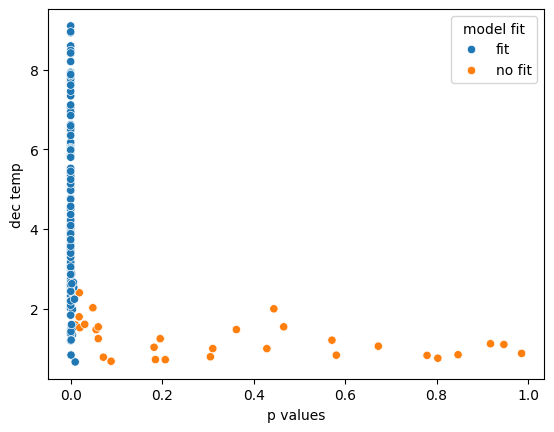

[7, 26, 34, 36, 41, 51, 82, 84, 89, 92, 100, 106, 108, 114, 115, 119, 123, 128, 143, 144, 152, 155, 157, 167, 170, 174, 175, 176, 181, 183]


In [24]:
ttest_results = []
BCC6_p_r_c_didnt_fit_choice = []
p_values = []
didnt_fit_str = []

null_hypothesis = -torch.log(torch.tensor(0.5))
significance_level = 0.01

random_choice_log_like = -torch.log(torch.tensor(1./na))*trials*(T-1)

for n in range(n_agents):
    ttest_results.append(ttest_1samp(BCC6_p_r_c_choice_log_like[:,n], null_hypothesis))
    p_values.append(ttest_results[-1].pvalue)
    #print(ttest_results[-1])
    if ttest_results[-1].pvalue > significance_level:
        #print(n)
        #print(ttest_results[-1])
        BCC6_p_r_c_didnt_fit_choice.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")

    # if BCC6_p_r_c_log_like[n] >= random_choice_log_like and BCC6_p_r_c_didnt_fit_choice[-1] != n:
    #     print("ttest and log like not in agreement", n)

    # if BCC6_p_r_c_log_like[n] < random_choice_log_like and n in BCC6_p_r_c_didnt_fit_choice:
    #     print("ttest and log like not in agreement", n)

p_values = torch.tensor(p_values)

print(len(BCC6_p_r_c_didnt_fit_choice), "participants have random behavior under the model (p>"+str(significance_level)+")")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"p values": p_values, "model fit": didnt_fit_str,
                                            "dec temp": BCC6_p_r_c_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="p values", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC6_p_r_c_1_mean_df["inferred dec temp"])

print(BCC6_p_r_c_didnt_fit_choice)


13 participants have random behavior compared to L0


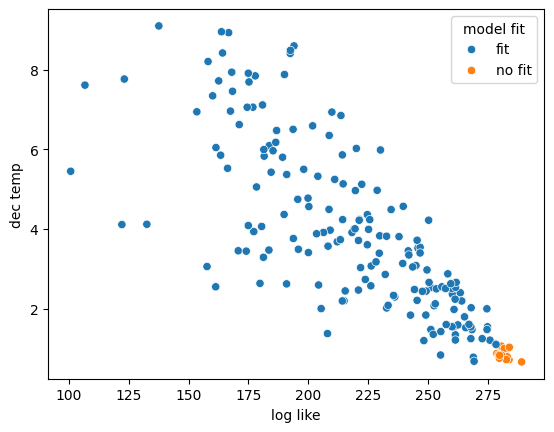

[82, 84, 89, 92, 106, 108, 119, 123, 129, 143, 155, 170, 183]


In [25]:
ttest_results = []
BCC6_p_r_c_didnt_fit_L0 = []
p_values = []
didnt_fit_str = []

random_choice_log_like = -torch.log(torch.tensor(1./na))*trials*(T-1)

for n in range(n_agents):

    if BCC6_p_r_c_log_like[n] >= random_choice_log_like:
        #print(n)
        #print(ttest_results[-1])
        BCC6_p_r_c_didnt_fit_L0.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")


p_values = torch.tensor(p_values)

print(len(BCC6_p_r_c_didnt_fit_L0), "participants have random behavior compared to L0")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"log like": BCC6_p_r_c_log_like, "model fit": didnt_fit_str,
                                            "dec temp": BCC6_p_r_c_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="log like", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC6_p_r_c_1_mean_df["inferred dec temp"])

print(BCC6_p_r_c_didnt_fit_L0)


## MFMB4 MF MB agent

In [26]:
# MFMB4 analysis

# set parameters and their names

learn_prior = False

use_orig = True

use_p = False
restrict_alpha = False
max_dt = 6

n_pars = 4

prefix = "MFMB"
agnt_str = ""

if use_orig:
    agnt_str += "_mf_mb_Orig"
    param_names = ["discount", "learning rate", "dec temp", "weight"]
    model_name = "original original w and beta model"
    param_ranges = [[0,1], [0,1], [0,8], [0,1]]
else:
    agnt_str += "_mf_mb"
    param_names = ["mb weight", "discount", "mf weight", "learning rate"]
    model_name = "two beta mbmf model"
    param_ranges = [[0,max_dt], [0,1], [0,max_dt], [0,1]]


if learn_prior:
    n_pars += 2
    param_names += ["prior lr", "prior weight"]
    param_ranges += [[0,1], [0,max_dt]]
    agnt_str += "_prior"

if use_p:
    n_pars += 1
    agnt_str += "_p"
    param_names += ["repetition"]
    
if restrict_alpha:
    agnt_str += "_resticted"
    min_alpha = 0.1
else:
    min_alpha = 0

max_dt = 6

# prepare for saving results
# make base filename and folder string
MFMB4_mf_mb_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str

MFMB4_mf_mb_agent_params = {"learn_prior": learn_prior, "use_p": use_p, "use_orig": use_orig, 
                            "restrict_alpha": restrict_alpha, "max_dt": max_dt, "min_alpha": min_alpha,
                            "param_names": param_names, "param_ranges": param_ranges}


In [27]:
MFMB4_mf_mb_fname_base = MFMB4_mf_mb_agent_type+"_inference_"
print(MFMB4_mf_mb_fname_base)
# define folder where we want to save data
MFMB4_mf_mb_base_dir = os.path.join(inference_folder,MFMB4_mf_mb_fname_base[:-1])

MFMB4_mf_mb_mean_df, MFMB4_mf_mb_sample_df, MFMB4_mf_mb_locs_df = \
    load_MFMB_results(MFMB4_mf_mb_agent_params["learn_prior"], MFMB4_mf_mb_agent_params["use_orig"], 
                      MFMB4_mf_mb_agent_params["use_p"], MFMB4_mf_mb_agent_params["restrict_alpha"], 
                      MFMB4_mf_mb_agent_params["min_alpha"], MFMB4_mf_mb_agent_params["max_dt"], 
                      MFMB4_mf_mb_base_dir, global_experiment_parameters, data["valid"], 
                      MFMB4_mf_mb_fname_base, num_steps, 
                      data, MFMB4_mf_mb_agent_params["param_names"])

MFMB4_mf_mb_agent = tu.set_up_mbmf_inference_agent(n_agents, MFMB4_mf_mb_agent_params["learn_prior"], 
                                                          MFMB4_mf_mb_agent_params["use_orig"], MFMB4_mf_mb_agent_params["use_p"], 
                                                          MFMB4_mf_mb_agent_params["restrict_alpha"], MFMB4_mf_mb_agent_params["max_dt"], 
                                                          MFMB4_mf_mb_agent_params["min_alpha"], 
                                                          MFMB4_mf_mb_base_dir, global_experiment_parameters, data["valid"], remove_old=False)

MFMB4_mf_mb_log_like = iu.calculate_log_likelihood(data, MFMB4_mf_mb_agent, MFMB4_mf_mb_locs_df, len(MFMB4_mf_mb_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"])

MFMB4_mf_mb_log_like = iu.calculate_log_likelihood(data, MFMB4_mf_mb_agent, MFMB4_mf_mb_locs_df, len(MFMB4_mf_mb_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"])

MFMB4_mf_mb_choice_log_like = -calculate_log_likelihood_mean_param(data, MFMB4_mf_mb_agent, MFMB4_mf_mb_locs_df, len(MFMB4_mf_mb_agent_params["param_names"]), global_experiment_parameters["trials"], global_experiment_parameters["T"])

MFMB_4pars_mf_mb_Orig_inference_
analyzing 188 data sets


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

31 participants have random behavior under the model (p>0.01)


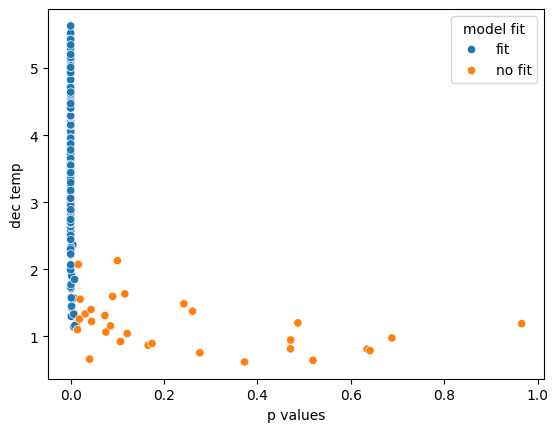

[7, 32, 34, 51, 75, 82, 84, 89, 92, 106, 108, 114, 117, 119, 120, 123, 128, 129, 143, 144, 145, 152, 155, 157, 167, 170, 174, 175, 176, 183, 187]


In [28]:
ttest_results = []
MFMB4_mf_mb_didnt_fit_choice = []
p_values = []
didnt_fit_str = []

null_hypothesis = -torch.log(torch.tensor(0.5))
significance_level = 0.01

random_choice_log_like = -torch.log(torch.tensor(1./na))*trials*(T-1)

for n in range(n_agents):
    ttest_results.append(ttest_1samp(MFMB4_mf_mb_choice_log_like[:,n], null_hypothesis))
    p_values.append(ttest_results[-1].pvalue)
    #print(ttest_results[-1])
    if ttest_results[-1].pvalue > significance_level:
        #print(n)
        #print(ttest_results[-1])
        MFMB4_mf_mb_didnt_fit_choice.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")

    # if MFMB4_mf_mb_log_like[n] >= random_choice_log_like and MFMB4_mf_mb_didnt_fit_choice[-1] != n:
    #     print("ttest and log like not in agreement", n)

    # if MFMB4_mf_mb_log_like[n] < random_choice_log_like and n in MFMB4_mf_mb_didnt_fit_choice:
    #     print("ttest and log like not in agreement", n)

p_values = torch.tensor(p_values)

print(len(MFMB4_mf_mb_didnt_fit_choice), "participants have random behavior under the model (p>"+str(significance_level)+")")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"p values": p_values, "model fit": didnt_fit_str,
                                            "dec temp": MFMB4_mf_mb_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="p values", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, MFMB4_mf_mb_1_mean_df["inferred dec temp"])

print(MFMB4_mf_mb_didnt_fit_choice)


5 participants have random behavior compared to L0


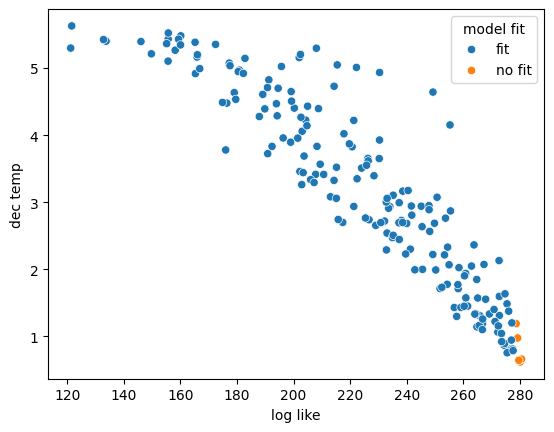

[82, 106, 129, 143, 170]


In [29]:
ttest_results = []
MFMB4_mf_mb_didnt_fit_L0 = []
p_values = []
didnt_fit_str = []

random_choice_log_like = -torch.log(torch.tensor(1./na))*trials*(T-1)

for n in range(n_agents):

    if MFMB4_mf_mb_log_like[n] >= random_choice_log_like:
        #print(n)
        #print(ttest_results[-1])
        MFMB4_mf_mb_didnt_fit_L0.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")


p_values = torch.tensor(p_values)

print(len(MFMB4_mf_mb_didnt_fit_L0), "participants have random behavior compared to L0")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"log like": MFMB4_mf_mb_log_like, "model fit": didnt_fit_str,
                                            "dec temp": MFMB4_mf_mb_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="log like", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, MFMB4_mf_mb_1_mean_df["inferred dec temp"])

print(MFMB4_mf_mb_didnt_fit_L0)


## MFMB6 MF MB agent & data

In [30]:
# MFMB6 analysis

# set parameters and their names

learn_prior = True

use_orig = True

use_p = False
restrict_alpha = False
max_dt = 6

n_pars = 4

prefix = "MFMB"
agnt_str = ""

if use_orig:
    agnt_str += "_mf_mb_Orig"
    param_names = ["discount", "learning rate", "dec temp", "weight"]
    model_name = "original original w and beta model"
    param_ranges = [[0,1], [0,1], [0,8], [0,1]]
else:
    agnt_str += "_mf_mb"
    param_names = ["mb weight", "discount", "mf weight", "learning rate"]
    model_name = "two beta mbmf model"
    param_ranges = [[0,max_dt], [0,1], [0,max_dt], [0,1]]


if learn_prior:
    n_pars += 2
    param_names += ["prior lr", "prior weight"]
    param_ranges += [[0,1], [0,max_dt]]
    agnt_str += "_prior"

if use_p:
    n_pars += 1
    agnt_str += "_p"
    param_names += ["repetition"]
    
if restrict_alpha:
    agnt_str += "_resticted"
    min_alpha = 0.1
else:
    min_alpha = 0

# prepare for saving results
# make base filename and folder string
MFMB6_mf_mb_prior_agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str

MFMB6_mf_mb_prior_agent_params = {"learn_prior": learn_prior, "use_p": use_p, "use_orig": use_orig, 
                            "restrict_alpha": restrict_alpha, "max_dt": max_dt, "min_alpha": min_alpha,
                            "param_names": param_names, "param_ranges": param_ranges}


In [31]:
MFMB6_mf_mb_prior_fname_base = MFMB6_mf_mb_prior_agent_type+"_inference_"
print(MFMB6_mf_mb_prior_fname_base)
# define folder where we want to save data
MFMB6_mf_mb_prior_base_dir = os.path.join(inference_folder,MFMB6_mf_mb_prior_fname_base[:-1])

MFMB6_mf_mb_prior_mean_df, MFMB6_mf_mb_prior_sample_df, MFMB6_mf_mb_prior_locs_df = \
    load_MFMB_results(MFMB6_mf_mb_prior_agent_params["learn_prior"], MFMB6_mf_mb_prior_agent_params["use_orig"], 
                      MFMB6_mf_mb_prior_agent_params["use_p"], MFMB6_mf_mb_prior_agent_params["restrict_alpha"], 
                      MFMB6_mf_mb_prior_agent_params["min_alpha"], MFMB6_mf_mb_prior_agent_params["max_dt"], 
                      MFMB6_mf_mb_prior_base_dir, global_experiment_parameters, data["valid"], 
                      MFMB6_mf_mb_prior_fname_base, num_steps, 
                      data, MFMB6_mf_mb_prior_agent_params["param_names"])

MFMB6_mf_mb_prior_agent = tu.set_up_mbmf_inference_agent(n_agents, MFMB6_mf_mb_prior_agent_params["learn_prior"], 
                                                          MFMB6_mf_mb_prior_agent_params["use_orig"], MFMB6_mf_mb_prior_agent_params["use_p"], 
                                                          MFMB6_mf_mb_prior_agent_params["restrict_alpha"], MFMB6_mf_mb_prior_agent_params["max_dt"], 
                                                          MFMB6_mf_mb_prior_agent_params["min_alpha"], 
                                                          MFMB6_mf_mb_prior_base_dir, global_experiment_parameters, data["valid"], remove_old=False)

MFMB6_mf_mb_prior_log_like = iu.calculate_log_likelihood(data, MFMB6_mf_mb_prior_agent, MFMB6_mf_mb_prior_locs_df, len(MFMB6_mf_mb_prior_agent_params["param_names"]), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"])

MFMB6_mf_mb_prior_choice_log_like = -calculate_log_likelihood_mean_param(data, MFMB6_mf_mb_prior_agent, MFMB6_mf_mb_prior_locs_df, len(MFMB6_mf_mb_prior_agent_params["param_names"]), global_experiment_parameters["trials"], global_experiment_parameters["T"])

MFMB_6pars_mf_mb_Orig_prior_inference_
analyzing 188 data sets


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

33 participants have random behavior under the model (p>0.01)


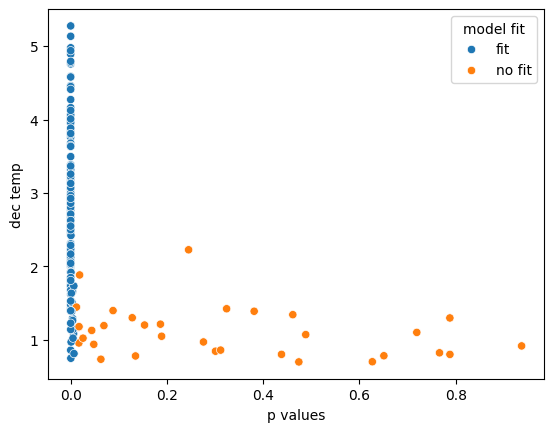

[2, 7, 32, 34, 41, 51, 75, 82, 84, 89, 92, 106, 108, 114, 116, 117, 119, 120, 123, 129, 143, 144, 145, 146, 152, 155, 157, 164, 167, 170, 175, 176, 183]


In [32]:
ttest_results = []
MFMB6_mf_mb_prior_didnt_fit_choice = []
p_values = []
didnt_fit_str = []

null_hypothesis = -torch.log(torch.tensor(0.5))
significance_level = 0.01

random_choice_log_like = -torch.log(torch.tensor(1./na))*trials*(T-1)

for n in range(n_agents):
    ttest_results.append(ttest_1samp(MFMB6_mf_mb_prior_choice_log_like[:,n], null_hypothesis))
    p_values.append(ttest_results[-1].pvalue)
    #print(ttest_results[-1])
    if ttest_results[-1].pvalue > significance_level:
        #print(n)
        #print(ttest_results[-1])
        MFMB6_mf_mb_prior_didnt_fit_choice.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")

    # if MFMB6_mf_mb_prior_log_like[n] >= random_choice_log_like and MFMB6_mf_mb_prior_didnt_fit_choice[-1] != n:
    #     print("ttest and log like not in agreement", n)

    # if MFMB6_mf_mb_prior_log_like[n] < random_choice_log_like and n in MFMB6_mf_mb_prior_didnt_fit_choice:
    #     print("ttest and log like not in agreement", n)

p_values = torch.tensor(p_values)

print(len(MFMB6_mf_mb_prior_didnt_fit_choice), "participants have random behavior under the model (p>"+str(significance_level)+")")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"p values": p_values, "model fit": didnt_fit_str,
                                            "dec temp": MFMB6_mf_mb_prior_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="p values", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, MFMB6_mf_mb_prior_1_mean_df["inferred dec temp"])

print(MFMB6_mf_mb_prior_didnt_fit_choice)


8 participants have random behavior compared to L0


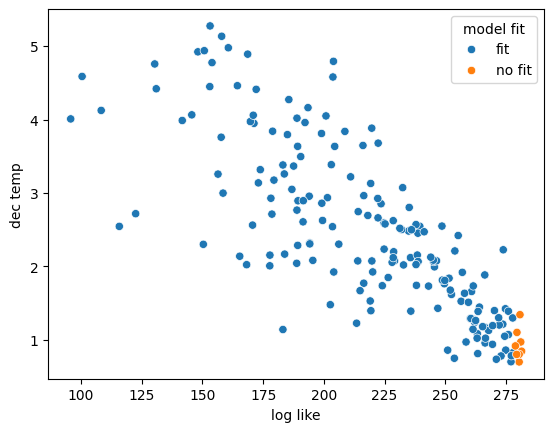

[82, 92, 106, 123, 129, 143, 157, 183]


In [33]:
ttest_results = []
MFMB6_mf_mb_prior_didnt_fit_L0 = []
p_values = []
didnt_fit_str = []

random_choice_log_like = -torch.log(torch.tensor(1./na))*trials*(T-1)

for n in range(n_agents):

    if MFMB6_mf_mb_prior_log_like[n] >= random_choice_log_like:
        #print(n)
        #print(ttest_results[-1])
        MFMB6_mf_mb_prior_didnt_fit_L0.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")


p_values = torch.tensor(p_values)

print(len(MFMB6_mf_mb_prior_didnt_fit_L0), "participants have random behavior compared to L0")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"log like": MFMB6_mf_mb_prior_log_like, "model fit": didnt_fit_str,
                                            "dec temp": MFMB6_mf_mb_prior_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="log like", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, MFMB6_mf_mb_prior_1_mean_df["inferred dec temp"])

print(MFMB6_mf_mb_prior_didnt_fit_L0)


In [34]:
# which participants dont fit in all models?

BCC_didnt_fit_choice = list(set(BCC2_p_didnt_fit_choice) & set(BCC4_p_r_didnt_fit_choice) \
                            & set(BCC4_p_c_didnt_fit_choice) & set(BCC6_p_r_c_didnt_fit_choice))

BCC_didnt_fit_L0 = list(set(BCC2_p_didnt_fit_L0) & set(BCC4_p_r_didnt_fit_L0) \
                            & set(BCC4_p_c_didnt_fit_L0) & set(BCC6_p_r_c_didnt_fit_L0))

MFMB_didnt_fit_choice = list(set(MFMB4_mf_mb_didnt_fit_choice) & set(MFMB6_mf_mb_prior_didnt_fit_choice))

MFMB_didnt_fit_L0 = list(set(MFMB4_mf_mb_didnt_fit_L0) & set(MFMB6_mf_mb_prior_didnt_fit_L0))

all_didnt_fit_choice = list(set(BCC_didnt_fit_choice) & set(MFMB_didnt_fit_choice))

all_didnt_fit_L0 = list(set(BCC_didnt_fit_L0) & set(MFMB_didnt_fit_L0))

print(len(all_didnt_fit_choice), "didnt fit in all the models according to choice probs:")
print(all_didnt_fit_choice)

print(len(all_didnt_fit_L0), "didnt fit in all the models according to L0:")
print(all_didnt_fit_L0)

with open(non_fit_file, "w") as f:
    json.dump(all_didnt_fit_choice, f)

21 didnt fit in all the models according to choice probs:
[7, 143, 144, 152, 155, 157, 34, 167, 170, 175, 176, 51, 183, 82, 84, 89, 92, 106, 108, 119, 123]
3 didnt fit in all the models according to L0:
[129, 82, 143]


In [35]:
MFMB4_sample_df.groupby("subject").std().mean()

NameError: name 'MFMB4_sample_df' is not defined

In [ ]:
MFMB5_sample_df.groupby("subject").std().mean()

Unnamed: 0       27162.584560
discount             0.129060
learning rate        0.104968
mf weight            0.509208
mb weight            0.379470
repetition           0.146294
dtype: float64

In [ ]:
test = torch.exp(-BCC3_log_like) > 1

print(test.sum())

tensor(0)


tensor(0.9996)


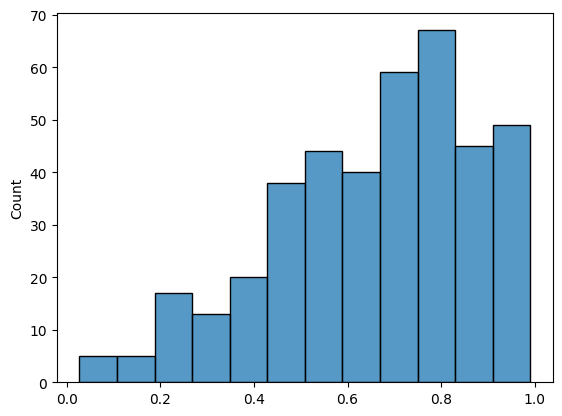

In [ ]:
#print(BCC3_log_like[...,0])
BCC3_like = torch.exp(-BCC3_log_like)
print(BCC3_like.amax())

plt.figure()
sns.histplot(BCC3_like[...,6])
plt.show()

tensor(1.0000)


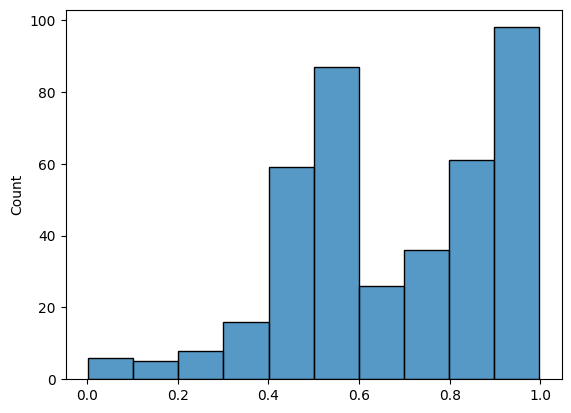

In [ ]:
MFMB4_like = torch.exp(-MFMB4_log_like)
print(MFMB4_like.amax())

plt.figure()
sns.histplot(MFMB4_like[...,6])
plt.show()

In [ ]:
BCC3_total_log_like = BCC3_log_like.sum(dim=0)
BCC4_total_log_like = BCC4_log_like.sum(dim=0)

MFMB4_total_log_like = MFMB4_log_like.sum(dim=0)
MFMB5_total_log_like = MFMB5_log_like.sum(dim=0)

all_total_log_likes = torch.stack([BCC3_total_log_like, BCC4_total_log_like, MFMB4_total_log_like, MFMB5_total_log_like], dim=-1)

winning_model = all_total_log_likes.argmin(dim=-1)

print("BCC3 wins", (winning_model==0).sum())
print("BCC4 wins", (winning_model==1).sum())
print("MFMB4 wins", (winning_model==2).sum())
print("MFMB5 wins", (winning_model==3).sum())


BCC3 wins tensor(21)
BCC4 wins tensor(53)
MFMB4 wins tensor(28)
MFMB5 wins tensor(86)


In [ ]:
all_total_log_likes = torch.stack([MFMB4_total_log_like, MFMB5_total_log_like, BCC3_total_log_like, BCC4_total_log_like], dim=-1)

winning_model = all_total_log_likes.argmin(dim=-1)

print("BCC3 wins", (winning_model==2).sum())
print("BCC4 wins", (winning_model==3).sum())
print("MFMB4 wins", (winning_model==0).sum())
print("MFMB5 wins", (winning_model==1).sum())

BCC3 wins tensor(21)
BCC4 wins tensor(53)
MFMB4 wins tensor(28)
MFMB5 wins tensor(86)


In [ ]:
delta_BCC3 = BCC3_total_log_like[...,None] - torch.stack([BCC4_total_log_like, MFMB4_total_log_like, MFMB5_total_log_like], dim=-1)

print(delta_BCC3)

tensor([[-4.2764e-01, -1.5099e+01, -1.3113e+01],
        [-6.7145e-01,  1.5053e+01,  1.7067e+01],
        [ 6.4163e-02, -8.3305e+00, -7.5755e+00],
        [-9.8605e-01,  1.2226e+01,  1.6700e+01],
        [-4.2235e-01,  1.3801e+01,  1.8142e+01],
        [-3.3357e-01,  2.9302e+01,  3.0570e+01],
        [-5.9622e-01,  8.0139e+00,  1.0157e+01],
        [ 6.1060e+00,  7.4107e+00,  7.2236e+00],
        [-5.1701e-01, -2.9250e-01,  5.0909e+00],
        [-2.2086e-01,  2.8071e+00,  3.6546e+00],
        [-5.5643e-01,  1.9962e+00,  4.6991e+00],
        [-5.1477e-01,  9.1530e+00,  1.2337e+01],
        [-9.6100e-02, -1.7253e+01, -1.5537e+01],
        [-6.2547e-01,  4.9406e+00,  9.9068e+00],
        [-5.5437e-01,  1.1717e+01,  1.3049e+01],
        [-4.2693e-01,  4.8539e+00,  4.3466e+00],
        [-8.0399e-01,  9.1694e+00,  1.1683e+01],
        [ 5.2164e-01, -4.2661e+00, -1.1474e+00],
        [-8.3612e-01,  2.5678e+01,  2.7203e+01],
        [ 7.7286e-02,  3.1141e+00,  2.5191e+00],
        [ 8.8466e-01